# 15 - Constructions in Euclidean Geometry

This notebook is an authored, executable replacement for Chapter 15 of *Geometric Algebra for Computer Science*. It follows the conceptual route of the printed chapter while using original explanations, local helper code, and numerical checks. The verified source span for orientation is printed pages 437-464, which correspond in this PDF to pages 464-491. The notebook does not require the PDF while running; that span is recorded so the study material has a stable anchor.

The chapter's practical question is this: once the conformal model lets points, planes, spheres, lines, circles, and tangents live in one algebraic setting, what constructions become natural? The answer is more than "we can intersect things." Meet, dual meet, contraction, and affine addition become geometric tools. A meet may return the common object shared by several elements. Its dual companion, often called a plunge in this chapter, builds the object that cuts into the arguments orthogonally. A tangent is no longer a limit of secants; it is a local contraction at the point of contact. A circle is not merely a sampled curve; it factors into a carrier flat and a surrounding sphere. Even the innocent act of interpolating two conformal point vectors produces a family of dual spheres rather than a family of points.

The code here uses transparent NumPy formulas as coordinate shadows of the conformal operations. That choice keeps the notebook inspectable. When a cell says that a point is incident with a sphere, it checks the conformal inner product against a dual sphere vector. When a cell says that a circle factors into a carrier and a surround, it samples the circle and verifies both constraints. The visualizations are meant to be read actively: change the input handles, rerun the cells, and watch which invariants survive.


## The Chapter Idea In One Picture

Euclidean construction in conformal geometric algebra is about replacing a cabinet of separate formulas with a small number of object-level operations. Classical analytic geometry often has one formula for a line-plane intersection, another for two spheres, another for the tangent to a circle, and still another for the projection of a point. The conformal model does not erase the geometric differences, but it lets the same operations speak across them.

The central pair is meet and plunge. Meet asks for common incidence: what object is shared by these inputs? Three spheres can meet in two points, two spheres can meet in a circle, and a plane and a sphere can meet in a circle. Plunge asks for a complementary orthogonal construction: what object dives through or into the inputs at right angles? For point-like zero-radius spheres, the plunge of three points is the circle through them. For mixed objects, it becomes a way to write down circles, flats, and auxiliary elements without switching notation.

A second theme is local structure. The tangent at a point is not treated as a separate differentiable curve calculation. If an element passes through a point, contraction with that point extracts the local tangent direction or tangent flat. In coordinates, the tangent line to a circle is perpendicular to the radius and lies in the carrier plane. The notebook checks both facts and compares the algebraic tangent with a finite-difference derivative only as a sanity check, not as the definition.

A third theme is factorization. A round such as a circle has two orthogonal pieces: a carrier flat and a surrounding sphere. Their intersection is the round. This split is computationally valuable because the carrier stores direction and orientation while the surround stores location and size. The factorization also explains why some projections and affine combinations feel surprising when first seen through the conformal model: the operation is acting on a full geometric object, not on a drawing convention.


## Translation Guide

| Geometric idea | Conformal GA language | Coordinate stand-in used here |
|---|---|---|
| Euclidean point | Null point vector $P(x)=x+n_o+\tfrac12\|x\|^2 n_\infty$ | A 5-vector plus its recovered 3-D coordinates |
| Dual sphere | Vector $\sigma=P(c)-\tfrac12 r^2 n_\infty$ | Center, squared radius, and the probe $-2P(x)\cdot\sigma$ |
| Dual plane | Unit vector $\pi=n+h n_\infty$ for $n\cdot x=h$ | Unit normal, offset, and signed-distance probe |
| Incidence | Probe or exterior product vanishes | Small residuals in the numeric tables |
| Meet | Largest common element of blades | Sphere-sphere radical circles and three-sphere point pairs |
| Plunge | Dual companion that intersects inputs orthogonally | Circumcircle through point-spheres and contour constructions |
| Tangent | Local contraction at a point | Tangent line checked against radial and carrier constraints |
| Carrier | Smallest flat containing a round | Plane of a circle |
| Surround | Smallest sphere containing a round | Sphere centered at the circle center with circle radius |
| Affine point sum | A normalized dual sphere family | Centers follow affine interpolation; radius squared may be negative |
| Projection | Conformal projection onto another element | Orthogonal projection onto a plane, with residual checks |

The table is intentionally bilingual. The left column is the geometry you can see, the middle column is the algebraic intent, and the right column is what the code actually manipulates. This makes each cell auditable: every algebraic claim is paired with a concrete residual or picture.


## Notebook Route

1. Import the chapter helper and record the verified PDF span.
2. Use conformal point, sphere, and plane probes to study incidence and coincidence.
3. Compute meets of spheres and a plunge-style circle through point-spheres.
4. Build tangents without differentiating, then compare against a finite-difference check.
5. Factor a round into its carrier plane and surrounding sphere.
6. Explore affine combinations of point vectors and why they become dual spheres.
7. Run applied construction labs: projection to a plane, a sphere contour circle, and a small Voronoi cell.
8. Finish with invariant assertions and artifact existence checks.

The route is deliberately cumulative. Later cells reuse the same objects in new roles, which is the point of the conformal model: one representation carries incidence, metric data, and construction logic together.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

PROJECT_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "utils" / "artifacts.py").exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.artifacts import save_json, save_matplotlib, save_plotly_html
from utils.chapter15_euclidean_constructions import (
    COLORS,
    Circle3D,
    Line3D,
    Plane3D,
    Sphere3D,
    affine_dual_sphere,
    carrier_plane,
    cga_inner,
    cga_norm2,
    circle_from_points,
    circle_trace,
    conformal_point,
    contour_circle_from_viewpoint,
    contour_tangent_residuals,
    curve_trace,
    distance_squared_from_inner,
    dual_plane_vector,
    factorization_residuals,
    finish_figure,
    finite_difference_tangent,
    flat_point_interpolation,
    line_trace,
    normalize,
    plane_probe,
    plane_surface_trace,
    point_trace,
    project_points_to_plane,
    sanity_checks,
    smallest_sphere_through_two_points,
    sphere_power,
    sphere_sphere_meet,
    sphere_surface_trace,
    surround_sphere,
    tangent_residual,
    three_sphere_meet,
)

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

ARTIFACT_ROOT = PROJECT_ROOT / "artifacts"
artifact_paths: list[Path] = []


## Shared Geometry Helpers

The reusable code lives in `utils/chapter15_euclidean_constructions.py`. Keeping it outside the notebook has two advantages. First, the construction cells stay readable: the visible code shows the mathematical choices rather than every plotting detail. Second, the helper can be linted and imported independently, which makes the chapter less fragile.

The helper uses the conformal coordinate order `[e1, e2, e3, no, ni]` with `no.ni = -1`. It provides conformal point embedding, dual sphere and plane probes, circle and sphere data classes, intersection routines, tangent checks, factorization checks, affine point combinations, and Plotly traces. It is not a general-purpose GA engine. That boundary is intentional. The notebook is a bridge between the algebraic chapter and executable geometric intuition.


In [2]:
SOURCE_SPAN = {
    "printed_pages": "437-464",
    "pdf_pages": "464-491",
    "previous_pdf_page": "463 ends Chapter 14 at printed p. 436",
    "next_pdf_page": "492 starts Chapter 16 at printed p. 465",
}

span_path = save_json(SOURCE_SPAN, "chapter-15", "metadata", "verified-source-span.json", root=ARTIFACT_ROOT)
artifact_paths.append(span_path)
print("Verified source span")
for key, value in SOURCE_SPAN.items():
    print(f"  {key}: {value}")
print("artifact:", span_path.relative_to(PROJECT_ROOT))


Verified source span
  printed_pages: 437-464
  pdf_pages: 464-491
  previous_pdf_page: 463 ends Chapter 14 at printed p. 436
  next_pdf_page: 492 starts Chapter 16 at printed p. 465
artifact: artifacts\chapter-15\metadata\verified-source-span.json


## Incidence: Probes Instead Of Casework

In the conformal model, the same inner product tests several familiar relationships. A normalized point vector is null: $P(x)\cdot P(x)=0$. Two normalized points recover their Euclidean distance by $-2P(a)\cdot P(b)=\|a-b\|^2$. A point lies on a dual sphere when the sphere power $\|x-c\|^2-r^2$ vanishes, and it lies on a unit dual plane when the signed-distance probe vanishes.

This is the first construction lesson of the chapter. Incidence is not merely a Boolean predicate attached to a particular data type. It is a uniform probe. The probe may represent distance, signed distance, or power depending on the element being tested, but the shape of the computation is shared.

The next cell builds a small scene with two points on a sphere, one point off it, and a plane through two of the points. The printed residuals are deliberately small rather than hidden behind `True` or `False`. In computational geometry, seeing the residual scale matters because exact symbolic incidence almost never survives floating-point input.


In [3]:
p = np.array([0.20, -0.70, 0.35])
q = np.array([1.05, 0.25, 0.10])
r = np.array([0.50, 0.35, 1.20])

sphere = Sphere3D.real(center=[0.35, -0.10, 0.25], radius=0.95)
p = sphere.center + sphere.radius * normalize(p - sphere.center)
q = sphere.center + sphere.radius * normalize(q - sphere.center)
plane = Plane3D.from_point_normal(point=p, normal=np.cross(q - p, r - p))

P = conformal_point(p)
Q = conformal_point(q)
R = conformal_point(r)
probe_rows = []
for label, x, X in [("p", p, P), ("q", q, Q), ("r", r, R)]:
    probe_rows.append(
        {
            "label": label,
            "point_null": cga_norm2(X),
            "sphere_power": sphere_power(x, sphere.vector),
            "plane_signed_distance": plane_probe(x, plane.vector),
        }
    )

incidence_path = save_json(probe_rows, "chapter-15", "tables", "incidence-probes.json", root=ARTIFACT_ROOT)
artifact_paths.append(incidence_path)

print("distance from conformal inner product:", distance_squared_from_inner(P, Q))
print("ordinary squared distance:           ", float(np.dot(p - q, p - q)))
print("\nprobe table")
for row in probe_rows:
    print(row)
print("artifact:", incidence_path.relative_to(PROJECT_ROOT))


distance from conformal inner product: 2.998120898866456
ordinary squared distance:            2.9981208988664565

probe table
{'label': 'p', 'point_null': 0.0, 'sphere_power': -0.0, 'plane_signed_distance': 0.0}
{'label': 'q', 'point_null': 0.0, 'sphere_power': -3.3306690738754696e-16, 'plane_signed_distance': 2.220446049250313e-16}
{'label': 'r', 'point_null': 0.0, 'sphere_power': 0.2250000000000001, 'plane_signed_distance': 1.1102230246251565e-16}
artifact: artifacts\chapter-15\tables\incidence-probes.json


In [4]:
fig_incidence = go.Figure()
fig_incidence.add_trace(sphere_surface_trace(sphere, "dual sphere sigma"))
fig_incidence.add_trace(plane_surface_trace(plane, "dual plane pi", size=1.45))
fig_incidence.add_trace(point_trace(np.array([p, q, r]), ["p", "q", "r"], COLORS["gray"], size=6))
fig_incidence.add_trace(curve_trace(np.array([p, q]), "chord pq", COLORS["orange"], width=5))
finish_figure(fig_incidence, "Incidence probes: points, a dual sphere, and a dual plane", height=620)

incidence_fig_path = save_plotly_html(
    fig_incidence,
    "chapter-15",
    "plots",
    "incidence-probes.html",
    root=ARTIFACT_ROOT,
)
artifact_paths.append(incidence_fig_path)
print("artifact:", incidence_fig_path.relative_to(PROJECT_ROOT))
fig_incidence


artifact: artifacts\chapter-15\plots\incidence-probes.html


## Coincidence: Different Descriptions, Same Constraint

Incidence says that a point satisfies an element. Coincidence asks whether two element descriptions impose the same geometric constraint. In exact GA one can compare blades up to scale. In numerical work, it is often safer to compare probes over a set of witness points.

Here we build the same plane in two ways. The first is the unit dual plane returned by the helper. The second is a scaled version of the same dual vector. They represent the same plane but give signed distances in different units. Normalizing the vector removes that scale. The cell also compares the plane with a genuinely different offset to show that this is not just a formatting exercise.

This is a modest example, but it mirrors a larger computational habit used throughout the conformal model: separate the representation from the incidence relation it induces. Two formulas can look different and still cut out the same geometry.


In [5]:
plane_scaled = 3.7 * plane.vector
plane_shifted = dual_plane_vector(plane.normal, plane.offset + 0.22)

witness = np.vstack([p, q, r, sphere.center, 0.5 * (p + q)])
unit_probe = np.array([plane_probe(x, plane.vector) for x in witness])
scaled_probe = np.array([plane_probe(x, plane_scaled / 3.7) for x in witness])
shifted_probe = np.array([plane_probe(x, plane_shifted) for x in witness])

coincidence_error = float(np.max(np.abs(unit_probe - scaled_probe)))
shift_error = float(np.max(np.abs(unit_probe - shifted_probe)))
assert coincidence_error < 1e-12
assert shift_error > 1e-2

print(f"same plane after scale normalization: {coincidence_error:.2e}")
print(f"changed plane offset residual:        {shift_error:.2e}")


same plane after scale normalization: 0.00e+00
changed plane offset residual:        2.20e-01


## Meet And Plunge

The meet of three spheres is the point pair common to all three. In coordinates, subtracting sphere equations gives a radical line, and intersecting that line with one sphere gives zero, one, or two points. In the conformal algebra this same construction is expressed as a meet of the dual sphere vectors. The type of result is part of the geometry: real point pair, tangent point, or imaginary point pair.

The plunge is the dual companion to meet. Its geometric personality is easiest to read in a limiting case: shrink three spheres to point-spheres. The plunge through those point-spheres is the circle through the three points. That circle is not a derivative or a fit; it is the simplest round that contains the point constraints and carries the orthogonal-construction meaning of the dual meet.

The figure below shows both ideas. The blue spheres have a real point-pair meet. The purple circle is the plunge-style circle through three independent point handles. The orange radical circle is the meet of two of the spheres; if the same two spheres are pulled apart so that they no longer intersect, the returned radius squared becomes negative, and the circle is interpreted as an imaginary meet with a real carrier location.


In [6]:
s1 = Sphere3D.real([0.0, 0.0, 0.0], 1.45)
s2 = Sphere3D.real([1.05, 0.20, 0.05], 1.15)
s3 = Sphere3D.real([0.35, 1.05, 0.20], 1.05)
meet = three_sphere_meet(s1, s2, s3)
radical_circle = sphere_sphere_meet(s1, s2)

plunge_handles = np.array([
    [-0.25, -0.45, 0.60],
    [0.85, -0.15, 0.35],
    [0.25, 0.85, -0.10],
])
plunge_circle = circle_from_points(plunge_handles)

fig_meet = go.Figure()
for sph, name, color in [
    (s1, "sphere a", "rgba(37,99,235,0.14)"),
    (s2, "sphere b", "rgba(22,163,74,0.14)"),
    (s3, "sphere c", "rgba(234,88,12,0.14)"),
]:
    fig_meet.add_trace(sphere_surface_trace(sph, name, color=color, samples=34))
fig_meet.add_trace(circle_trace(radical_circle.circle, "meet(a,b): radical circle", COLORS["orange"], width=7))
fig_meet.add_trace(circle_trace(plunge_circle, "plunge through three point-spheres", COLORS["purple"], width=7))
fig_meet.add_trace(point_trace(plunge_handles, ["a0", "b0", "c0"], COLORS["gray"], size=5))
if meet.points.size:
    fig_meet.add_trace(point_trace(meet.points, [f"m{i}" for i in range(len(meet.points))], COLORS["red"], size=7))
fig_meet.add_trace(curve_trace(meet.radical_point + np.linspace(-1.3, 1.3, 80)[:, None] * meet.radical_direction, "radical line", COLORS["cyan"], width=4))
finish_figure(fig_meet, "Meet and plunge: sphere intersections and a circle through point-spheres", height=680)

meet_path = save_plotly_html(fig_meet, "chapter-15", "plots", "meet-and-plunge.html", root=ARTIFACT_ROOT)
artifact_paths.append(meet_path)
print("three-sphere meet kind:", meet.kind)
print("two-sphere meet kind:", radical_circle.kind, "radius^2 =", radical_circle.radius_squared)
print("artifact:", meet_path.relative_to(PROJECT_ROOT))
fig_meet


three-sphere meet kind: real point pair
two-sphere meet kind: real circle radius^2 = 1.2934115720524013
artifact: artifacts\chapter-15\plots\meet-and-plunge.html


In [7]:
if meet.points.size:
    meet_powers = np.column_stack([s1.power(meet.points), s2.power(meet.points), s3.power(meet.points)])
    meet_residual = float(np.max(np.abs(meet_powers)))
else:
    meet_residual = float("nan")
plunge_residual = float(np.max(plunge_circle.residuals(plunge_handles)))

far_sphere = Sphere3D.real([3.10, 0.20, 0.05], 1.15)
imaginary_meet = sphere_sphere_meet(s1, far_sphere)
assert meet.kind == "real point pair"
assert meet_residual < 1e-9
assert plunge_residual < 1e-9
assert imaginary_meet.radius_squared < 0.0

print(f"three-sphere meet power residual: {meet_residual:.2e}")
print(f"plunge circle through handles:    {plunge_residual:.2e}")
print(f"separated two-sphere meet:        {imaginary_meet.kind}, radius^2={imaginary_meet.radius_squared:.3f}")


three-sphere meet power residual: 4.44e-16
plunge circle through handles:    2.22e-16
separated two-sphere meet:        imaginary circle, radius^2=-0.716


## Tangents Without Differentiating

A tangent in this chapter is a local construction, not an afterthought from calculus. If a round or flat contains a point, contracting the point into the element extracts the tangent object at that point. For a circle, the coordinate shadow is familiar: the tangent line lies in the carrier plane and is perpendicular to the radial vector from the center to the point of contact.

The next figure makes those three constraints visible. The green curve is the circle. The red point is the chosen point of contact. The orange segment shows the radial direction. The purple line is the tangent. The finite-difference derivative is computed only to confirm that the local construction agrees with the sampled curve; the tangent's definition is the incidence-and-contraction relationship.


In [8]:
tangent_circle = Circle3D.through_three_points(
    [1.10, -0.20, 0.15],
    [0.05, 1.05, -0.20],
    [-0.95, -0.10, 0.30],
)
tangent_angle = 0.92
tangent_point = tangent_circle.point_at_angle(tangent_angle)
tangent_line = tangent_circle.tangent_line_at(tangent_point)
radial_line = Line3D(tangent_circle.center, tangent_point - tangent_circle.center)
fd_direction = finite_difference_tangent(tangent_circle, tangent_angle)
fd_line = Line3D(tangent_point, fd_direction)

fig_tangent = go.Figure()
fig_tangent.add_trace(circle_trace(tangent_circle, "circle", COLORS["green"], width=8))
fig_tangent.add_trace(line_trace(tangent_line, "tangent", COLORS["purple"], t_min=-0.9, t_max=0.9, width=7))
fig_tangent.add_trace(line_trace(fd_line, "finite-difference direction", COLORS["cyan"], t_min=-0.75, t_max=0.75, width=4))
fig_tangent.add_trace(curve_trace(np.array([tangent_circle.center, tangent_point]), "radius", COLORS["orange"], width=6))
fig_tangent.add_trace(point_trace(np.array([tangent_circle.center, tangent_point]), ["center", "p"], COLORS["red"], size=6))
finish_figure(fig_tangent, "Tangent as a local conformal construction", height=620)

tangent_path = save_plotly_html(fig_tangent, "chapter-15", "plots", "tangent-without-differentiating.html", root=ARTIFACT_ROOT)
artifact_paths.append(tangent_path)
print("artifact:", tangent_path.relative_to(PROJECT_ROOT))
fig_tangent


artifact: artifacts\chapter-15\plots\tangent-without-differentiating.html


In [9]:
tangent_checks = tangent_residual(tangent_circle, tangent_point)
alignment = abs(float(np.dot(tangent_line.direction, fd_direction)))
assert tangent_checks["point_on_circle"] < 1e-9
assert tangent_checks["tangent_radial_dot"] < 1e-9
assert tangent_checks["tangent_in_carrier_dot"] < 1e-9
assert abs(1.0 - alignment) < 1e-9

for key, value in tangent_checks.items():
    print(f"{key}: {value:.2e}")
print(f"finite-difference alignment: {alignment:.12f}")


point_on_circle: 0.00e+00
tangent_radial_dot: 1.25e-16
tangent_in_carrier_dot: 5.55e-17
finite-difference alignment: 1.000000000000


## Carriers, Surrounds, And Factorization Of Rounds

A round can be split into the flat that carries its directions and the sphere that surrounds its location. For a circle, the carrier is a plane and the surround is the smallest sphere containing the circle. Their intersection recovers the circle. This is the geometric content of the factorization formulas in the chapter: direction and size are orthogonal pieces of one object.

The distinction is useful in code. If you want to test whether a point belongs to the circle, you can check two simpler constraints: the point lies in the carrier plane, and it lies on the surround sphere. If you want to transform the circle, both pieces transform covariantly. If you want to understand a projection or a tangent, the carrier often explains the direction while the surround explains the distance scale.

The next scene draws the circle, its translucent carrier plane, and its translucent surrounding sphere. The checks sample points from the circle and verify that both constraints vanish to floating-point tolerance.


In [10]:
factor_circle = Circle3D.through_three_points(
    [0.95, 0.20, 0.20],
    [-0.15, 0.95, -0.15],
    [-0.70, -0.35, 0.45],
)
factor_carrier = carrier_plane(factor_circle)
factor_surround = surround_sphere(factor_circle)

fig_factor = go.Figure()
fig_factor.add_trace(sphere_surface_trace(factor_surround, "surround sphere", color="rgba(37,99,235,0.16)", samples=36))
fig_factor.add_trace(plane_surface_trace(factor_carrier, "carrier plane", size=1.45, color="rgba(250,204,21,0.30)"))
fig_factor.add_trace(circle_trace(factor_circle, "circle = carrier meet surround", COLORS["pink"], width=8))
fig_factor.add_trace(point_trace(np.array([factor_circle.center]), ["center"], COLORS["gray"], size=6))
finish_figure(fig_factor, "Round factorization: carrier plane plus surrounding sphere", height=650)

factor_path = save_plotly_html(fig_factor, "chapter-15", "plots", "round-factorization.html", root=ARTIFACT_ROOT)
artifact_paths.append(factor_path)
print("carrier normal:", factor_carrier.normal)
print("surround center/radius:", factor_surround.center, factor_surround.radius)
print("artifact:", factor_path.relative_to(PROJECT_ROOT))
fig_factor


carrier normal: [-0.0025  0.4199  0.9076]
surround center/radius: [0.0387 0.1388 0.2258] 0.9137147769878678
artifact: artifacts\chapter-15\plots\round-factorization.html


In [11]:
factor_checks = factorization_residuals(factor_circle)
assert factor_checks["carrier_plane_max_distance"] < 1e-9
assert factor_checks["surround_sphere_max_power"] < 1e-9
for key, value in factor_checks.items():
    print(f"{key}: {value:.2e}")


carrier_plane_max_distance: 1.11e-16
surround_sphere_max_power: 3.33e-16


## Affine Combinations: Points Become Dual Spheres

One of the most memorable surprises in this chapter is that an affine combination of normalized conformal point vectors is usually not a point vector. For two points $p$ and $q$, the vector

$$
\lambda P(p) + (1-\lambda)P(q)
$$

has finite weight one, so it can be decoded as a dual sphere. Its center follows the ordinary affine interpolation between $p$ and $q$, but its squared radius is

$$
r^2 = -\lambda(1-\lambda)\|p-q\|^2.
$$

Between the endpoints, that squared radius is negative, so the interpolating object is an imaginary dual sphere. Outside the interval, it becomes a real dual sphere. If you want literal points along the segment, interpolate flat points instead. The conformal model is not being perverse; it is preserving more metric information than the homogeneous point model did.

The Matplotlib plot below shows the 2-D cross-section of this family. Centers travel along the straight segment. Circles with positive radius squared are drawn solid; imaginary ones are shown as dashed footprints using the magnitude of the radius squared. The printed table records the algebraic data.


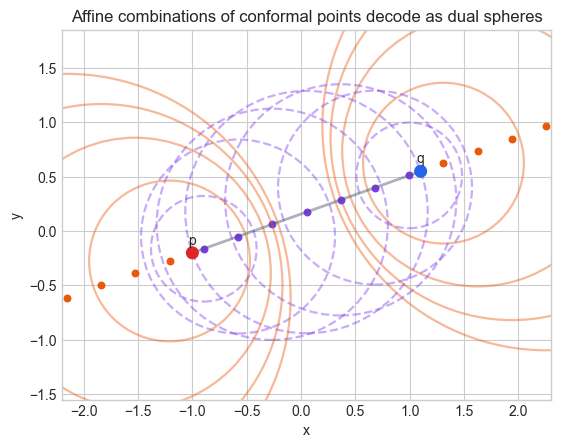

lambda, center, radius_squared, orthogonal_to_smallest_sphere
-0.55  [2.255  0.9625]   4.2391   0.00e+00
-0.25  [1.625  0.7375]   1.5539   0.00e+00
 0.05  [0.995  0.5125]  -0.2362   0.00e+00
 0.35  [0.365  0.2875]  -1.1312   0.00e+00
 0.65  [-0.265   0.0625]  -1.1312   0.00e+00
 0.95  [-0.895  -0.1625]  -0.2362  -1.11e-16
 1.25  [-1.525  -0.3875]   1.5539  -1.11e-16
 1.55  [-2.155  -0.6125]   4.2391  -1.11e-16
artifact: artifacts\chapter-15\plots\affine-dual-spheres.png


In [12]:
ap = np.array([-1.00, -0.20, 0.0])
aq = np.array([1.10, 0.55, 0.0])
lambdas = np.linspace(-0.55, 1.55, 15)
affine_samples = [affine_dual_sphere(ap, aq, lam) for lam in lambdas]
surround_pq = smallest_sphere_through_two_points(ap, aq)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.scatter([ap[0], aq[0]], [ap[1], aq[1]], color=[COLORS["red"], COLORS["blue"]], s=70, zorder=3)
ax.text(ap[0], ap[1] + 0.08, "p", ha="center")
ax.text(aq[0], aq[1] + 0.08, "q", ha="center")
ax.plot([ap[0], aq[0]], [ap[1], aq[1]], color=COLORS["gray"], linewidth=2, alpha=0.45)

for sample in affine_samples:
    center = sample.center
    radius = float(np.sqrt(abs(sample.radius_squared)))
    style = "-" if sample.radius_squared >= 0 else "--"
    color = COLORS["orange"] if sample.radius_squared >= 0 else COLORS["purple"]
    circle_artist = plt.Circle((center[0], center[1]), radius, fill=False, linestyle=style, color=color, alpha=0.42, linewidth=1.6)
    ax.add_artist(circle_artist)
    ax.scatter(center[0], center[1], color=color, s=22)

ax.set_aspect("equal", adjustable="box")
ax.set_title("Affine combinations of conformal points decode as dual spheres")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(-2.2, 2.3)
ax.set_ylim(-1.55, 1.85)

affine_path = save_matplotlib(fig, "chapter-15", "plots", "affine-dual-spheres.png", root=ARTIFACT_ROOT, dpi=170)
artifact_paths.append(affine_path)
plt.show()

print("lambda, center, radius_squared, orthogonal_to_smallest_sphere")
for sample in affine_samples[::2]:
    ortho = cga_inner(sample.vector, surround_pq.vector)
    print(f"{sample.lam:5.2f}  {sample.center[:2]}  {sample.radius_squared: .4f}  {ortho: .2e}")
print("artifact:", affine_path.relative_to(PROJECT_ROOT))


In [13]:
d2 = float(np.dot(ap - aq, ap - aq))
affine_errors = []
for sample in affine_samples:
    expected_center = flat_point_interpolation(ap, aq, sample.lam)
    expected_radius_squared = -sample.lam * (1.0 - sample.lam) * d2
    affine_errors.append(
        max(
            float(np.linalg.norm(sample.center - expected_center)),
            abs(sample.radius_squared - expected_radius_squared),
            abs(cga_inner(sample.vector, surround_pq.vector)),
        )
    )
max_affine_error = max(affine_errors)
assert max_affine_error < 1e-9
print(f"max affine center/radius/orthogonality residual: {max_affine_error:.2e}")


max affine center/radius/orthogonality residual: 1.33e-15


## Applied Lab: Projection Onto A Plane

The chapter emphasizes that projection in the conformal model applies to geometric elements, not just isolated coordinates. For a flat target such as a plane, the coordinate shadow is the familiar orthogonal projection: subtract the signed distance along the plane normal. For a round such as a circle, we can project sampled points to see the curve drawn on the plane, then verify that every projected sample is incident with the target plane.

This lab also makes a useful warning visible. The projected sample curve is not a new arbitrary circle object just because the original was a circle. A projection can change the apparent radius and shape in the drawing plane. The conformal operation is still well defined, but interpreting the result requires attention to the carrier and surround of the original element.


In [14]:
projection_plane = Plane3D.from_point_normal([0.15, -0.25, 0.05], [0.25, -0.55, 1.0])
projection_circle = Circle3D.through_three_points(
    [1.0, -0.45, 0.55],
    [0.05, 1.05, 0.15],
    [-0.85, -0.20, -0.15],
)
projection_samples = projection_circle.sample(220)
projected_samples = project_points_to_plane(projection_samples, projection_plane)
projection_residual = float(np.max(np.abs(projection_plane.signed_distance(projected_samples))))

fig_projection = go.Figure()
fig_projection.add_trace(plane_surface_trace(projection_plane, "projection plane", size=1.8))
fig_projection.add_trace(circle_trace(projection_circle, "original circle", COLORS["green"], width=7))
fig_projection.add_trace(curve_trace(projected_samples, "orthogonal projection", COLORS["cyan"], width=8))
for idx in np.linspace(0, len(projection_samples) - 1, 12, dtype=int):
    fig_projection.add_trace(curve_trace(np.array([projection_samples[idx], projected_samples[idx]]), "projection ray", COLORS["light_gray"], width=2))
finish_figure(fig_projection, "Projection of a round onto a flat", height=650)

projection_path = save_plotly_html(fig_projection, "chapter-15", "plots", "projection-to-plane.html", root=ARTIFACT_ROOT)
artifact_paths.append(projection_path)
assert projection_residual < 1e-9
print(f"projected samples plane residual: {projection_residual:.2e}")
print("artifact:", projection_path.relative_to(PROJECT_ROOT))
fig_projection


projected samples plane residual: 1.94e-16
artifact: artifacts\chapter-15\plots\projection-to-plane.html


## Applied Lab: A Contour Circle As A Plunge-Style Construction

A sphere seen from an external point has a contour circle: the circle of contact points where sight lines are tangent to the sphere. In conformal terms this is a natural construction because the desired circle is constrained by a point, a sphere, and orthogonality. In elementary coordinates, the contact circle lies in the plane perpendicular to the eye-center axis, at distance $r^2/d$ from the sphere center, with radius $r\sqrt{d^2-r^2}/d$.

The cell below computes that circle and checks the two defining conditions. Every contour point lies on the sphere, and the radius to that point is perpendicular to the sight line from the eye. This is a good example of the chapter's larger message: a compact object-level construction expands into several classical equations, but the geometric intent is simple.


In [15]:
view_sphere = Sphere3D.real([0.05, -0.15, 0.20], 0.82)
eye = np.array([2.30, 1.20, 1.45])
contour = contour_circle_from_viewpoint(view_sphere, eye)
contour_checks = contour_tangent_residuals(view_sphere, eye, contour)

fig_contour = go.Figure()
fig_contour.add_trace(sphere_surface_trace(view_sphere, "viewed sphere", color="rgba(37,99,235,0.18)", samples=38))
fig_contour.add_trace(circle_trace(contour, "contour circle", COLORS["red"], width=8))
fig_contour.add_trace(point_trace(np.array([eye, view_sphere.center]), ["eye", "center"], COLORS["gray"], size=6))
for point in contour.sample(12, endpoint=False):
    fig_contour.add_trace(curve_trace(np.array([eye, point]), "tangent sight line", "rgba(71,85,105,0.35)", width=2))
finish_figure(fig_contour, "Contour circle from an external viewpoint", height=650)

contour_path = save_plotly_html(fig_contour, "chapter-15", "plots", "contour-circle.html", root=ARTIFACT_ROOT)
artifact_paths.append(contour_path)
assert contour_checks["sphere_power_max"] < 1e-9
assert contour_checks["radius_sight_dot_max"] < 1e-9
for key, value in contour_checks.items():
    print(f"{key}: {value:.2e}")
print("artifact:", contour_path.relative_to(PROJECT_ROOT))
fig_contour


sphere_power_max: 3.33e-16
radius_sight_dot_max: 6.66e-16
artifact: artifacts\chapter-15\plots\contour-circle.html


## Applied Lab: A Voronoi Cell From Half-Plane Incidence

The printed chapter closes with a planar construction around Voronoi geometry. The conformal model gives a coordinate-free way to name the edge lines and edge points, but the visible result can be checked with ordinary half-plane clipping. A Voronoi edge between a site $s_0$ and a neighbor $s_i$ is the perpendicular bisector of the segment joining them. The cell of $s_0$ is the intersection of all half-planes containing points closer to $s_0$ than to each neighbor.

This small lab keeps the algorithm explicit. Each bisector is a plane in the 2-D drawing plane. Each clipping step is a meet-like operation: intersect the current polygon with one more incidence constraint. The final polygon is not used elsewhere in the notebook, but it demonstrates how the chapter's construction language scales from isolated objects to a short geometric algorithm.


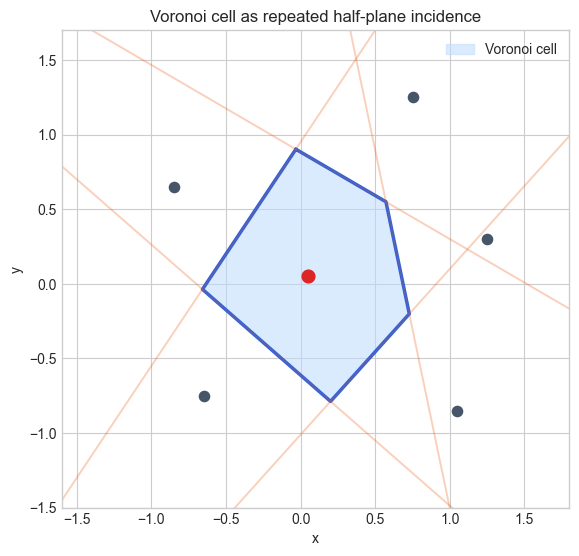

Voronoi half-plane margin: -8.88e-16
artifact: artifacts\chapter-15\plots\voronoi-cell.png


In [16]:
def clip_polygon_halfplane(poly: np.ndarray, normal: np.ndarray, offset: float, tol: float = 1e-12) -> np.ndarray:
    # Clip a 2-D polygon to normal.x <= offset.
    result = []
    if len(poly) == 0:
        return poly
    prev = poly[-1]
    prev_inside = float(np.dot(normal, prev)) <= offset + tol
    for curr in poly:
        curr_inside = float(np.dot(normal, curr)) <= offset + tol
        segment = curr - prev
        denom = float(np.dot(normal, segment))
        if curr_inside != prev_inside and abs(denom) > tol:
            t = (offset - float(np.dot(normal, prev))) / denom
            result.append(prev + t * segment)
        if curr_inside:
            result.append(curr)
        prev, prev_inside = curr, curr_inside
    return np.array(result, dtype=float)

sites = np.array([
    [0.05, 0.05],
    [1.25, 0.30],
    [-0.85, 0.65],
    [0.75, 1.25],
    [-0.65, -0.75],
    [1.05, -0.85],
])
site0 = sites[0]
cell = np.array([[-2.0, -2.0], [2.0, -2.0], [2.0, 2.0], [-2.0, 2.0]], dtype=float)
bisectors = []
for neighbor in sites[1:]:
    normal = neighbor - site0
    offset = 0.5 * (float(np.dot(neighbor, neighbor)) - float(np.dot(site0, site0)))
    bisectors.append((normal, offset))
    cell = clip_polygon_halfplane(cell, normal, offset)

closed_cell = np.vstack([cell, cell[0]])
fig_v, ax = plt.subplots(figsize=(7.2, 6.2))
ax.scatter(sites[:, 0], sites[:, 1], color=COLORS["gray"], s=54, zorder=3)
ax.scatter([site0[0]], [site0[1]], color=COLORS["red"], s=84, zorder=4)
ax.fill(cell[:, 0], cell[:, 1], color="#bfdbfe", alpha=0.55, label="Voronoi cell")
ax.plot(closed_cell[:, 0], closed_cell[:, 1], color=COLORS["blue"], linewidth=2.5)
xx = np.linspace(-1.6, 1.8, 120)
for normal, offset in bisectors:
    if abs(normal[1]) > 1e-9:
        yy = (offset - normal[0] * xx) / normal[1]
        ax.plot(xx, yy, color=COLORS["orange"], alpha=0.28, linewidth=1.4)
    else:
        ax.axvline(offset / normal[0], color=COLORS["orange"], alpha=0.28, linewidth=1.4)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.6, 1.8)
ax.set_ylim(-1.5, 1.7)
ax.set_title("Voronoi cell as repeated half-plane incidence")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")

voronoi_path = save_matplotlib(fig_v, "chapter-15", "plots", "voronoi-cell.png", root=ARTIFACT_ROOT, dpi=170)
artifact_paths.append(voronoi_path)
plt.show()

margin = []
for vertex in cell:
    d0 = float(np.dot(vertex - site0, vertex - site0))
    margin.extend(float(np.dot(vertex - neighbor, vertex - neighbor) - d0) for neighbor in sites[1:])
min_margin = min(margin)
assert min_margin > -1e-9
print(f"Voronoi half-plane margin: {min_margin:.2e}")
print("artifact:", voronoi_path.relative_to(PROJECT_ROOT))


## Final Sanity Checks

The last code cell is a quality gate rather than a new idea. It imports the helper's compact `sanity_checks()` suite, asserts that each numerical invariant is near zero, and verifies that every artifact path accumulated by the notebook exists on disk. These checks are intentionally redundant with earlier cells. Redundancy is useful in an executable chapter because it catches accidental edits to inputs, paths, or helper functions.

The thresholds are set at ordinary double-precision scales. If you experiment with nearly tangent or nearly degenerate configurations, you may need looser tolerances. For the authored examples in this notebook, the residuals should be many orders of magnitude smaller than the plotted geometry.


In [17]:
checks = sanity_checks()
thresholds = {
    "point_null_residual": 1e-12,
    "distance_identity_residual": 1e-12,
    "sphere_power_residual": 1e-12,
    "three_sphere_meet_power_residual": 1e-9,
    "tangent_radial_dot": 1e-12,
    "tangent_finite_difference_alignment": 1e-9,
    "factorization_carrier_residual": 1e-12,
    "factorization_surround_residual": 1e-12,
    "affine_center_residual": 1e-12,
    "affine_radius_squared_residual": 1e-12,
    "affine_surround_orthogonality": 1e-12,
    "projection_plane_residual": 1e-12,
    "contour_sphere_residual": 1e-12,
    "contour_tangent_residual": 1e-12,
}
for key, value in checks.items():
    assert abs(value) <= thresholds[key], f"{key}={value} exceeds {thresholds[key]}"

missing = [path for path in artifact_paths if not Path(path).exists()]
assert not missing, missing
assert len(artifact_paths) >= 9

print("chapter sanity checks passed")
for key, value in checks.items():
    print(f"{key}: {value:.2e}")
print("\nartifacts")
for path in artifact_paths:
    print("-", Path(path).relative_to(PROJECT_ROOT))


chapter sanity checks passed
point_null_residual: 0.00e+00
distance_identity_residual: 4.44e-16
sphere_power_residual: 0.00e+00
three_sphere_meet_power_residual: 8.88e-16
tangent_radial_dot: 9.71e-17
tangent_finite_difference_alignment: -2.22e-16
factorization_carrier_residual: 1.11e-16
factorization_surround_residual: 4.44e-16
affine_center_residual: 0.00e+00
affine_radius_squared_residual: 1.11e-16
affine_surround_orthogonality: 1.67e-16
projection_plane_residual: 2.22e-16
contour_sphere_residual: 4.44e-16
contour_tangent_residual: 6.66e-16

artifacts
- artifacts\chapter-15\metadata\verified-source-span.json
- artifacts\chapter-15\tables\incidence-probes.json
- artifacts\chapter-15\plots\incidence-probes.html
- artifacts\chapter-15\plots\meet-and-plunge.html
- artifacts\chapter-15\plots\tangent-without-differentiating.html
- artifacts\chapter-15\plots\round-factorization.html
- artifacts\chapter-15\plots\affine-dual-spheres.png
- artifacts\chapter-15\plots\projection-to-plane.html
- 

## Chapter Takeaways

Meet is the incidence workhorse. In the coordinate cells it appears as radical planes, radical lines, and point-pair intersections, but the conceptual shape is the same: find the common object implied by the inputs. The result can be real, tangent, or imaginary, and the code should preserve that distinction instead of forcing every answer into a visible curve.

Plunge is the orthogonal companion. It is easiest to trust after seeing simple cases: the circle through three point-spheres, the contour circle of a sphere from a viewpoint, and auxiliary objects that cut the inputs perpendicularly. Once you recognize that pattern, many Euclidean constructions become easier to specify because you name the desired object directly.

Tangents, carriers, and surrounds show how local and global structure fit together. A tangent is obtained at the point of contact; a carrier stores the flat direction of a round; a surround stores its location and size. Their residual checks are small because the constraints are not decorative labels but executable definitions.

Affine combinations warn us that conformal points are richer than homogeneous points. A weighted sum of normalized point vectors follows the affine center path, but it usually represents a dual sphere, often with negative squared radius. To interpolate literal points, interpolate flat points or use the appropriate transformation operator.

The unifying programming lesson is to write geometry at the level of objects and probes. A notebook like this still uses coordinate formulas, but the formulas are organized around conformal questions: What is incident? What is common? What is perpendicular? What is the carrier? What is the surround? Those questions are the constructive vocabulary Chapter 15 adds to the conformal model.
